In [40]:
import numpy as np
import random as rnd
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns





E[x_1 , ... , x_n] = E[y* mu] = E[y] * E[mu]= 2 * mu 

In [41]:
# Generate the data
n = 1_000
mu = 7
EM_ITER = 600
sigma = 1
X = []
for i in range(n):
    y = np.random.choice([1, 2, 3]) 
    x_i = np.random.normal(y * mu, 1)  
    X.append(x_i)


In [42]:

def pdf_gauss(mu , sigma , x):
    return (1 / (sigma * math.sqrt(2*math.pi))) * math.exp(-((x - mu)**2) / (2*sigma**2))

len(X), np.mean(X)



(1000, 13.769467012664322)

In [43]:
m1 , m2 , m3 = 3 , 6 , 9
data = [dict(iter = 0 , m1=m1, m2=m2 , m3=m3)]
for i in range(1, EM_ITER):
    sum_r1 , sum_r2 , sum_r3 = 0 , 0 , 0
    m1_share_sum , m2_share_sum , m3_share_sum = 0 , 0 , 0
    for x_i in X:
        pdf_1 = pdf_gauss(m1 , sigma , x_i)
        pdf_2 = pdf_gauss(m2 , sigma , x_i)
        pdf_3 = pdf_gauss(m3 , sigma , x_i)
        total_pdf = sum([pdf_1, pdf_2, pdf_3])
        responsibility_1 = pdf_1 / total_pdf 
        responsibility_2 = pdf_2 / total_pdf
        responsibility_3 = pdf_3 / total_pdf

        sum_r1 += responsibility_1
        sum_r2 += responsibility_2
        sum_r3 += responsibility_3
        
        m1_share = responsibility_1 * x_i
        m2_share = responsibility_2 * x_i
        m3_share = responsibility_3 * x_i

        m1_share_sum += m1_share 
        m2_share_sum += m2_share 
        m3_share_sum += m3_share 

    
    m1 =  m1_share_sum / sum_r1
    m2 =  m2_share_sum / sum_r2
    m3 =  m3_share_sum / sum_r3

    data.append(dict(iter=i ,m1=m1, m2=m2 , m3=m3))

print(m1, m2 , m3)

7.053699392528413 14.049674544261723 20.988871549767524


In [44]:
# Convert the tracked data into a Pandas DataFrame
df = pd.DataFrame(data)


In [45]:
df.head()

,iter,m1,m2,m3
0,0,3.000000,6.000000,9.000000
1,1,5.270173,6.606554,15.908403
2,2,6.305421,7.344319,17.360634
3,3,6.605700,7.819904,17.489568
4,4,6.632549,8.266987,17.576714


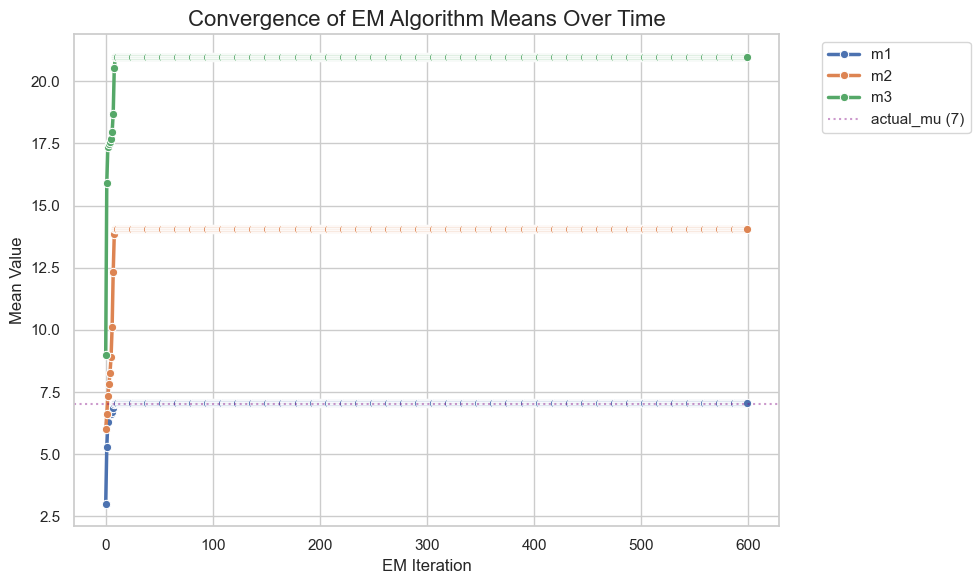

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your DataFrame with columns: ['iter', 'm1', 'm2', 'm3']
# And 'mu' is your list/array of actual means, e.g., mu = [1.5, 4.5, 7.0]

# 1. Melt the dataframe to reshape it for Seaborn
# We use 'iter' as the ID variable since that's your column name
df_melted = df.melt(id_vars=['iter'], value_vars=['m1', 'm2', 'm3'], 
                    var_name='Cluster', value_name='Mean Value')

# 2. Set the visual style and figure size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Plot the progression of the means
# Note that x='iter' to match your DataFrame
sns.lineplot(data=df_melted, x='iter', y='Mean Value', hue='Cluster', 
             marker='o', linewidth=2.5)

# 4. Add horizontal lines for the actual mu values
colors = ['blue', 'orange', 'green'] # Matches default seaborn hues
plt.axhline(y=mu, color='purple', linestyle=':', alpha=0.4, 
            label=f'actual_mu ({mu})')

# 5. Formatting the plot
plt.title('Convergence of EM Algorithm Means Over Time', fontsize=16)
plt.xlabel('EM Iteration', fontsize=12)
plt.ylabel('Mean Value', fontsize=12)

# Adjust the legend so it doesn't overlap the lines
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Display the plot
plt.show()